In [53]:
import torch
import h5py
import matplotlib.pyplot as plt
import numpy as np
import pickle
import importlib
import utils; importlib.reload(utils)

<module 'utils' from '/home/aj17/github_aza/FusionAIHub/scripts/explore/utils.py'>

In [39]:
with open('/scratch/gpfs/aj17/datasets/fm_test/dynamicmodel/dataset/206527_df.pkl','rb') as fid:
    data = pickle.load(fid)
print(data.keys())

dict_keys(['bolo', 'alpha', 'bcoil', 'dstdenp', 'iptipp', 'aminor', 'kappa', 'tritop', 'tribot', 'betan', 'bt', 'ip', 'ipsip', 'ece', 'tsne', 'tste', 'co2', 'gas', 'ech', 'nbi'])


In [19]:
data['nbi'].index[1000]

np.float32(50.0)

<Axes: xlabel='time'>

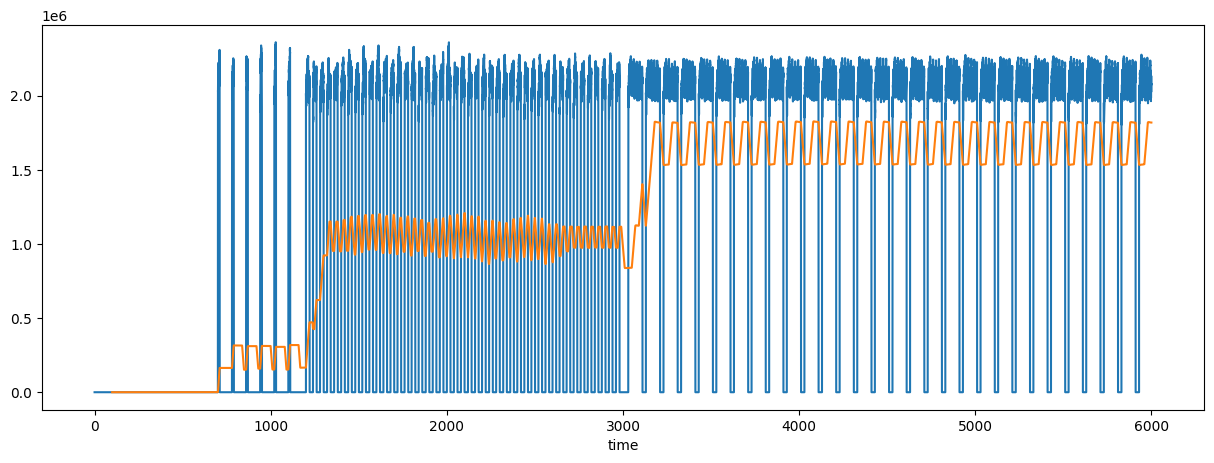

In [44]:
fig, axs = plt.subplots(ncols=1, nrows=1, figsize=(15,5))
data['nbi']['bmspinj33l'].plot(ax=axs)
data['nbi']['bmspinj33l'].rolling(window=2000).mean().plot(ax=axs)

# t = data['nbi'].index.to_numpy()
# y = data['nbi']['bmspinj33l'].to_numpy()
# y_filt = utils.filter_lp(y,t,3)
# axs.plot(t,y_filt)

<Axes: xlabel='time'>

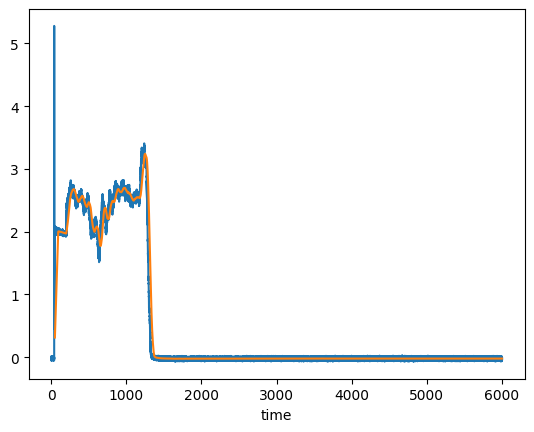

In [42]:
fig, axs = plt.subplots(ncols=1, nrows=1)
data['gas']['gasa'].plot(ax=axs)
data['gas']['gasa'].rolling(window=1000).mean().plot(ax=axs)


(0.0, 7.0)

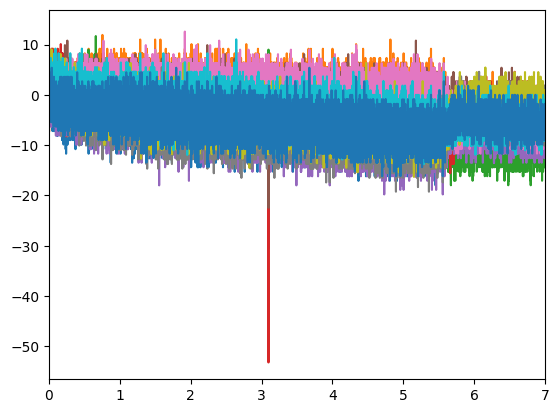

In [25]:
k = 'rmp'#sig_list[0]
_=plt.plot(data[k]['xdata'],data[k]['ydata'].T)
plt.xlim([0,7])

In [2]:

pnbi = dict()
ech = dict()
for shotn in [204370, 204853]:
    with h5py.File(f"/scratch/gpfs/EKOLEMEN/foundation_model/{shotn}_processed.h5",'r') as hf:
        pnbi[shotn] = {'x_pinj':np.asarray(hf['pinj']['xdata']),
                'y_pinj':np.asarray(hf['pinj']['ydata']),
                'x_tinj':np.asarray(hf['tinj']['xdata']),
                'y_tinj':np.asarray(hf['tinj']['ydata']),
                }
        ech[shotn] = {'x_ech':np.asarray(hf['ech']['xdata']),
                'y_ech':np.asarray(hf['ech']['ydata'])
                }

KeyError: "Unable to synchronously open object (object 'ech' doesn't exist)"

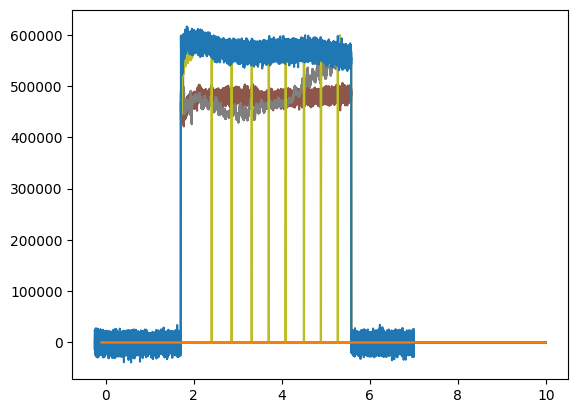

In [265]:
_=plt.plot(ech[204370]['x_ech'],ech[204370]['y_ech'].T)

In [14]:
data = dict()
arr = dict()
scal = dict()
for shotn in [204370, 204853,206539]:
    data[shotn]=dict()
    arr[shotn]=[]
    scal[shotn]=[]
    with h5py.File(f"/scratch/gpfs/aj17/datasets/D3D_shot_{shotn}_mdsplus.h5",'r') as hf:
        for k in hf.keys():
            data[shotn][k]=dict()
            try:        
                for k2 in hf[k].keys():
                    data[shotn][k][k2] = np.asarray(hf[k][k2])
                arr[shotn].append(k)
            except:
                data[shotn][k]=np.asarray(hf[k])
                scal[shotn].append(k)

In [82]:
for k in arr:
    print(k, data[k]['values'])

\D3D::TOP.NB.NB15L.BEAMTARGET nan
\D3D::TOP.NB.NB15L.BEAMTARGET:ACTUAL [0 0 0 ... 0 0 0]
\D3D::TOP.NB.NB15L.BEAMTARGET:BEAMCOM [[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[b'0']]]]]]]]]]]]]]]]]]]]]]]]]]]]]]]]
\D3D::TOP.NB.NB15L.BEAMTARGET:BEAMPROG [[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[b'0']]]]]]]]]]]]]]]]]]]]]]]]]]]]]]]]
\D3D::TOP.NB.NB15L.BEAMTARGET:DIFF [0. 0. 0. ... 0. 0. 0.]
\D3D::TOP.NB.NB15L.BEAMTARGET:DUR [5700    0    0    0    0    0    0    0    0]
\D3D::TOP.NB.NB15L.BEAMTARGET:OFFTRAIN [0 0 0 0 0 0 0 0 0]
\D3D::TOP.NB.NB15L.BEAMTARGET:ONTRAIN [5700    0    0    0    0    0    0    0    0]
\D3D::TOP.NB.NB15L.BEAMTARGET:PHASE [0 1 2 3 4 5 6 7 8]
\D3D::TOP.NB.NB15L.BEAMTARGET:START [600   0   0   0   0   0   0   0   0]
\D3D::TOP.NB.NB15L.BEAMTARGET:STATE [[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[b'15LT: PRIMARY, NO SUBSTITUTUION, ANNEX SWITCH: PCS']]]]]]]]]]]]]]]]]]]]]]]]]]]]]]]]
\D3D::TOP.NB.NB15L.BEAMTARGET:TARGET [0. 0. 0. ... 0. 0. 0.]
\D3D::TOP.NB.NB15L.BEAMTARGET:TARGETF [[[[[[[[[[[[[[[[[[[[[[[[[[[[[

\D3D::TOP.NB.NB15L:PABS


<>:3: SyntaxWarning: invalid escape sequence '\D'
<>:3: SyntaxWarning: invalid escape sequence '\D'
/tmp/ipykernel_1513767/2571336932.py:3: SyntaxWarning: invalid escape sequence '\D'
  k = "\D3D::TOP.NB.NB15L:PABS"


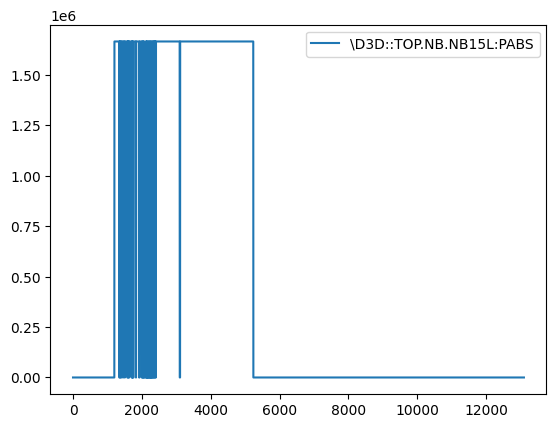

In [7]:
# idx = 0
# idx+=1
k = "\D3D::TOP.NB.NB15L:PABS"
print(k)
plt.plot(data[k]['time'],data[k]['values'],label=k)
plt.legend()


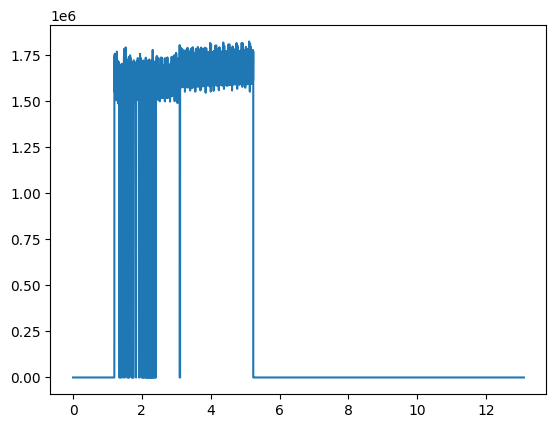

In [97]:
_=plt.plot(pnbi['x_pinj'],pnbi['y_pinj'][0,:])

In [222]:
# idx = 0
idx+=1
k = scal[idx]
print(k, data[k])


\D3D::TOP.NB.NB21L:CURRENT nan


In [156]:
scal

['\\D3D::TOP.NB.NB15L.BEAMTARGET:ACTUALF',
 '\\D3D::TOP.NB.NB15L.BEAMTARGET:DIFFF',
 '\\D3D::TOP.NB.NB15L:BEAMSTATF',
 '\\D3D::TOP.NB.NB15L:CURRENT',
 '\\D3D::TOP.NB.NB15L:F0',
 '\\D3D::TOP.NB.NB15L:PERVEANCE',
 '\\D3D::TOP.NB.NB15L:POWER',
 '\\D3D::TOP.NB.NB15L:PTDATA_RAWF',
 '\\D3D::TOP.NB.NB15L:VOLTAGE',
 '\\D3D::TOP.NB.NB15L:VOLTAGE_CALF',
 '\\D3D::TOP.NB.NB15R.BEAMTARGET:ACTUALF',
 '\\D3D::TOP.NB.NB15R.BEAMTARGET:DIFFF',
 '\\D3D::TOP.NB.NB15R:BEAMSTATF',
 '\\D3D::TOP.NB.NB15R:CURRENT',
 '\\D3D::TOP.NB.NB15R:F0',
 '\\D3D::TOP.NB.NB15R:PERVEANCE',
 '\\D3D::TOP.NB.NB15R:POWER',
 '\\D3D::TOP.NB.NB15R:PTDATA_RAWF',
 '\\D3D::TOP.NB.NB15R:VOLTAGE',
 '\\D3D::TOP.NB.NB15R:VOLTAGE_CALF',
 '\\D3D::TOP.NB.NB21L.BEAMTARGET:ACTUALF',
 '\\D3D::TOP.NB.NB21L.BEAMTARGET:DIFFF',
 '\\D3D::TOP.NB.NB21L.OANB',
 '\\D3D::TOP.NB.NB21L.OANB:BLPTCH_CAD',
 '\\D3D::TOP.NB.NB21L.OANB:BLPTCH_INCL',
 '\\D3D::TOP.NB.NB21L.OANB:CYLLTH_F',
 '\\D3D::TOP.NB.NB21L.OANB:CYLLTH_LR',
 '\\D3D::TOP.NB.NB21L.OANB:CYLLTH_RR'

In [5]:
data["\D3D::TOP.NB.NB15L:PABS"]

<>:1: SyntaxWarning: invalid escape sequence '\D'
<>:1: SyntaxWarning: invalid escape sequence '\D'
/tmp/ipykernel_1513767/2784590166.py:1: SyntaxWarning: invalid escape sequence '\D'
  data["\D3D::TOP.NB.NB15L:PABS"]


{'radial_pos': array(nan),
 'time': array([0.00000e+00, 1.00000e-01, 2.00000e-01, ..., 1.30998e+04,
        1.30999e+04, 1.31000e+04], shape=(131001,), dtype=float32),
 'values': array([0., 0., 0., ..., 0., 0., 0.], shape=(131001,), dtype=float32)}

In [116]:
siglist = [
    "\\D3D::TOP.RF.ECH.BORIS:ECBORAZIANG",
"\\D3D::TOP.RF.ECH.BORIS:ECBORFPWRC",
"\\D3D::TOP.RF.ECH.BORIS:ECBORPOLANG",
"\\D3D::TOP.RF.ECH.BORIS:ECBORPOLCNT",
"\\D3D::TOP.RF.ECH.BORIS:ECBORSTAT",
"\\D3D::TOP.RF.ECH.BORIS:ECBORTORCNT",
"\\D3D::TOP.RF.ECH.BORIS:ECBORXMFRAC",
"\\D3D::TOP.RF.ECH.CHEWBACCA:ECCHEAZIANG",
"\\D3D::TOP.RF.ECH.CHEWBACCA:ECCHEFPWRC",
"\\D3D::TOP.RF.ECH.CHEWBACCA:ECCHEPOLANG",
"\\D3D::TOP.RF.ECH.CHEWBACCA:ECCHEPOLCNT",
"\\D3D::TOP.RF.ECH.CHEWBACCA:ECCHESTAT",
"\\D3D::TOP.RF.ECH.CHEWBACCA:ECCHETORCNT",
"\\D3D::TOP.RF.ECH.CHEWBACCA:ECCHEXMFRAC",
"\\D3D::TOP.RF.ECH.DOROTHY:ECDORAZIANG",
"\\D3D::TOP.RF.ECH.DOROTHY:ECDORFPWRC",
"\\D3D::TOP.RF.ECH.DOROTHY:ECDORPOLANG",
"\\D3D::TOP.RF.ECH.DOROTHY:ECDORPOLCNT",
"\\D3D::TOP.RF.ECH.DOROTHY:ECDORSTAT",
"\\D3D::TOP.RF.ECH.DOROTHY:ECDORTORCNT",
"\\D3D::TOP.RF.ECH.DOROTHY:ECDORXMFRAC",
"\\D3D::TOP.RF.ECH.HAN:ECHANAZIANG",
"\\D3D::TOP.RF.ECH.HAN:ECHANDLPWRC",
"\\D3D::TOP.RF.ECH.HAN:ECHANPOLANG",
"\\D3D::TOP.RF.ECH.HAN:ECHANPOLCNT",
"\\D3D::TOP.RF.ECH.HAN:ECHANSTAT",
"\\D3D::TOP.RF.ECH.HAN:ECHANTORCNT",
"\\D3D::TOP.RF.ECH.HAN:ECHANXMFRAC",
"\\D3D::TOP.RF.ECH.KATYA:ECKATAZIANG",
"\\D3D::TOP.RF.ECH.KATYA:ECKATFPWRC",
"\\D3D::TOP.RF.ECH.KATYA:ECKATPOLANG",
"\\D3D::TOP.RF.ECH.KATYA:ECKATPOLCNT",
"\\D3D::TOP.RF.ECH.KATYA:ECKATSTAT",
"\\D3D::TOP.RF.ECH.KATYA:ECKATTORCNT",
"\\D3D::TOP.RF.ECH.KATYA:ECKATXMFRAC",
"\\D3D::TOP.RF.ECH.LEIA:ECLEIAZIANG",
"\\D3D::TOP.RF.ECH.LEIA:ECLEIFPWRC",
"\\D3D::TOP.RF.ECH.LEIA:ECLEIPOLANG",
"\\D3D::TOP.RF.ECH.LEIA:ECLEIPOLCNT",
"\\D3D::TOP.RF.ECH.LEIA:ECLEISTAT",
"\\D3D::TOP.RF.ECH.LEIA:ECLEITORCNT",
"\\D3D::TOP.RF.ECH.LEIA:ECLEIXMFRAC",
"\\D3D::TOP.RF.ECH.LION:ECLIOAZIANG",
"\\D3D::TOP.RF.ECH.LION:ECLIOFPWRC",
"\\D3D::TOP.RF.ECH.LION:ECLIOPOLANG",
"\\D3D::TOP.RF.ECH.LION:ECLIOPOLCNT",
"\\D3D::TOP.RF.ECH.LION:ECLIOSTAT",
"\\D3D::TOP.RF.ECH.LION:ECLIOTORCNT",
"\\D3D::TOP.RF.ECH.LION:ECLIOXMFRAC",
"\\D3D::TOP.RF.ECH.LUKE:ECLUKAZIANG",
"\\D3D::TOP.RF.ECH.LUKE:ECLUKFPWRC",
"\\D3D::TOP.RF.ECH.LUKE:ECLUKPOLANG",
"\\D3D::TOP.RF.ECH.LUKE:ECLUKPOLCNT",
"\\D3D::TOP.RF.ECH.LUKE:ECLUKSTAT",
"\\D3D::TOP.RF.ECH.LUKE:ECLUKTORCNT",
"\\D3D::TOP.RF.ECH.LUKE:ECLUKXMFRAC",
"\\D3D::TOP.RF.ECH.NASA:ECNASAZIANG",
"\\D3D::TOP.RF.ECH.NASA:ECNASFPWRC",
"\\D3D::TOP.RF.ECH.NASA:ECNASPOLANG",
"\\D3D::TOP.RF.ECH.NASA:ECNASPOLCNT",
"\\D3D::TOP.RF.ECH.NASA:ECNASSTAT",
"\\D3D::TOP.RF.ECH.NASA:ECNASTORCNT",
"\\D3D::TOP.RF.ECH.NASA:ECNASXMFRAC",
"\\D3D::TOP.RF.ECH.NATASHA:ECNATAZIANG",
"\\D3D::TOP.RF.ECH.NATASHA:ECNATFPWRC",
"\\D3D::TOP.RF.ECH.NATASHA:ECNATPOLANG",
"\\D3D::TOP.RF.ECH.NATASHA:ECNATPOLCNT",
"\\D3D::TOP.RF.ECH.NATASHA:ECNATSTAT",
"\\D3D::TOP.RF.ECH.NATASHA:ECNATTORCNT",
"\\D3D::TOP.RF.ECH.NATASHA:ECNATXMFRAC",
"\\D3D::TOP.RF.ECH.R2D2:ECR2DAZIANG",
"\\D3D::TOP.RF.ECH.R2D2:ECR2DFPWRC",
"\\D3D::TOP.RF.ECH.R2D2:ECR2DPOLANG",
"\\D3D::TOP.RF.ECH.R2D2:ECR2DPOLCNT",
"\\D3D::TOP.RF.ECH.R2D2:ECR2DSTAT",
"\\D3D::TOP.RF.ECH.R2D2:ECR2DTORCNT",
"\\D3D::TOP.RF.ECH.R2D2:ECR2DXMFRAC",
"\\D3D::TOP.RF.ECH.SCARECROW:ECSCAAZIANG",
"\\D3D::TOP.RF.ECH.SCARECROW:ECSCAFPWRC",
"\\D3D::TOP.RF.ECH.SCARECROW:ECSCAPOLANG",
"\\D3D::TOP.RF.ECH.SCARECROW:ECSCAPOLCNT",
"\\D3D::TOP.RF.ECH.SCARECROW:ECSCASTAT",
"\\D3D::TOP.RF.ECH.SCARECROW:ECSCATORCNT",
"\\D3D::TOP.RF.ECH.SCARECROW:ECSCAXMFRAC"
]

\D3D::TOP.RF.ECH.BORIS:ECBORSTAT {'radial_pos': array(nan), 'time': array(nan), 'values': array([[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[b'0W']]]]]]]]]]]]]]]]]]]]]]]]]]]]]]]],
      dtype='|S2')}
\D3D::TOP.RF.ECH.BORIS:ECBORSTAT {'radial_pos': array(nan), 'time': array(nan), 'values': array([[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[b'0W']]]]]]]]]]]]]]]]]]]]]]]]]]]]]]]],
      dtype='|S2')}
\D3D::TOP.RF.ECH.BORIS:ECBORSTAT {'radial_pos': array(nan), 'time': array(nan), 'values': array([[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[b'0W']]]]]]]]]]]]]]]]]]]]]]]]]]]]]]]],
      dtype='|S2')}


TypeError: unhashable type: 'numpy.ndarray'

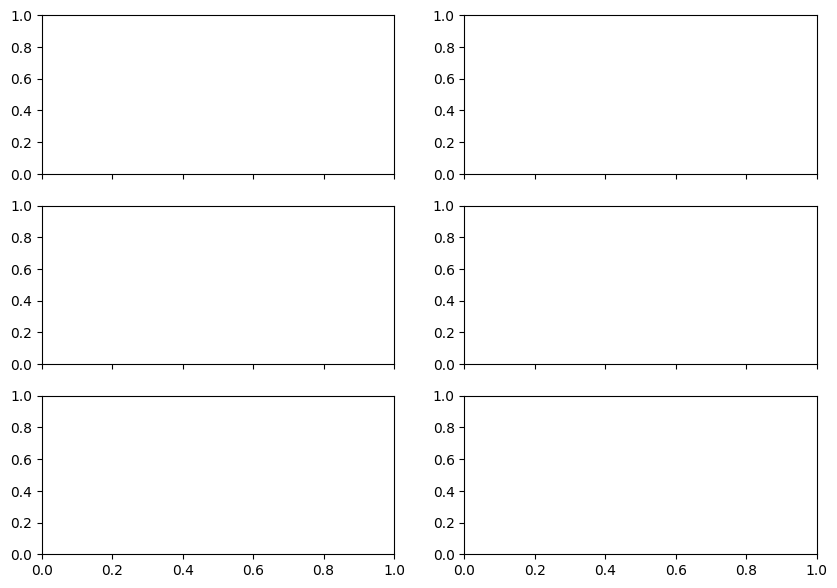

In [125]:
# idx = 0
idx += 1 
for shotn in [204370, 204853,206539]:
    print(siglist[idx], data[shotn][siglist[idx]])

fig, axs = plt.subplots(nrows = 3, ncols =2,sharex=True,figsize=(10,7))
shotn = 204370
# axs[0,0].plot(pnbi[shotn]['x_pinj']*1000,pnbi[shotn]['y_pinj'][0,:])
# axs[1,0].plot(pnbi[shotn]['x_tinj']*1000,pnbi[shotn]['y_tinj'][0,:])
axs[2,0].plot(data[shotn][siglist[idx]]['time'],data[shotn][siglist[idx]]['values'])
axs[0,0].set(xlim=[0,6000])

shotn = 204853
# axs[0,1].plot(pnbi[shotn]['x_pinj']*1000,pnbi[shotn]['y_pinj'][0,:])
# axs[1,1].plot(pnbi[shotn]['x_tinj']*1000,pnbi[shotn]['y_tinj'][0,:])
axs[2,1].plot(data[shotn][siglist[idx]]['time'],data[shotn][siglist[idx]]['values'])
axs[0,1].set(xlim=[0,6000])

In [108]:
data[204370]["\\D3D::TOP.NB.NB15R:NBVAC_SCALAR"]

{'radial_pos': array(nan),
 'time': array(nan),
 'values': array([[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[[b'72625.8']]]]]]]]]]]]]]]]]]]]]]]]]]]]]]]],
       dtype='|S7')}

[(0.0, 6000.0)]

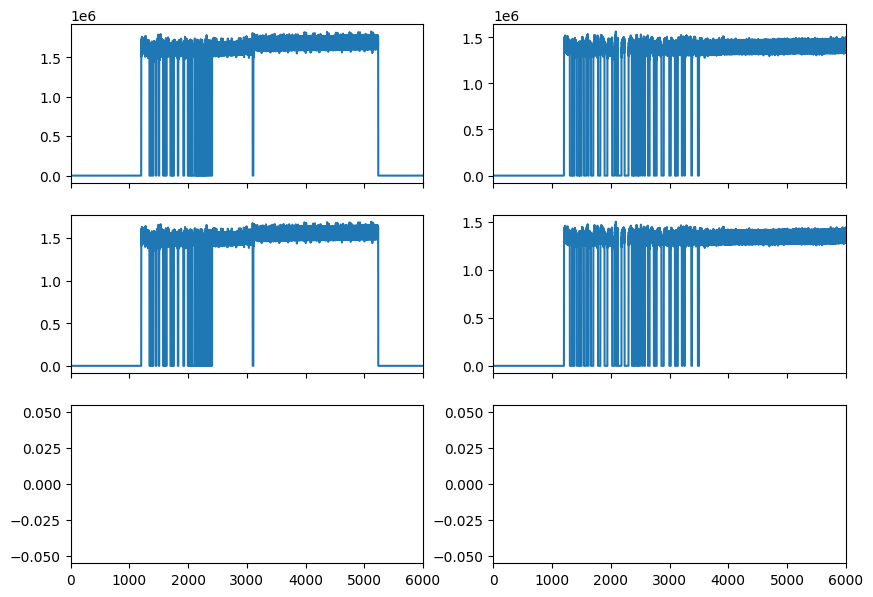

In [52]:
fig, axs = plt.subplots(nrows = 3, ncols =2,sharex=True,figsize=(10,7))
shotn = 204370
axs[0,0].plot(pnbi[shotn]['x_pinj']*1000,pnbi[shotn]['y_pinj'][0,:])
axs[1,0].plot(pnbi[shotn]['x_tinj']*1000,pnbi[shotn]['y_tinj'][0,:])
axs[2,0].plot(data[shotn][siglist[idx]]['time'],data[shotn][siglist[idx]]['values'])
axs[0,0].set(xlim=[0,6000])

shotn = 204853
axs[0,1].plot(pnbi[shotn]['x_pinj']*1000,pnbi[shotn]['y_pinj'][0,:])
axs[1,1].plot(pnbi[shotn]['x_tinj']*1000,pnbi[shotn]['y_tinj'][0,:])
axs[2,1].plot(data[shotn][siglist[idx]]['time'],data[shotn][siglist[idx]]['values'])
axs[0,1].set(xlim=[0,6000])

In [127]:
ech_name=['BORIS',
          'CHEWBACCA',
          'DOROTHY',
          'HAN',
          'KATYA',
          'LEIA',
          'LION',
          'LUKE',
          'NASA',
          'NATASHA',
          'R2D2',
          'SCARECROW'
         ]



NameError: name 'echn' is not defined

In [279]:
shotn = 204370

# ec_idx = 0
ec_idx += 1
echn = ech_name[ec_idx]

ech_path = [
    f"\\D3D::TOP.RF.ECH.{echn}:EC{echn[:3]}AZIANG",
    f"\\D3D::TOP.RF.ECH.{echn}:EC{echn[:3]}FPWRC",
    f"\\D3D::TOP.RF.ECH.{echn}:EC{echn[:3]}POLANG",
    f"\\D3D::TOP.RF.ECH.{echn}:EC{echn[:3]}POLCNT",
    f"\\D3D::TOP.RF.ECH.{echn}:EC{echn[:3]}TORCNT",
    f"\\D3D::TOP.RF.ECH.{echn}:EC{echn[:3]}XMFRAC",
    # f"\\D3D::TOP.RF.ECH.{echn}:EC{echn[:3]}STAT",
]

data =dict()
with h5py.File(f"/scratch/gpfs/aj17/datasets/D3D_shot_{shotn}_mdsplus.h5",'r') as hf:
    for k in ech_path:
        data[k]=dict()
        for k2 in hf[k]:
            data[k][k2] = np.asarray(hf[k][k2])

for k,v in data.items():
    plt.plot(v['time'],v['values'])
_=plt.title(echn)   

IndexError: list index out of range

TypeError: unhashable type: 'numpy.ndarray'

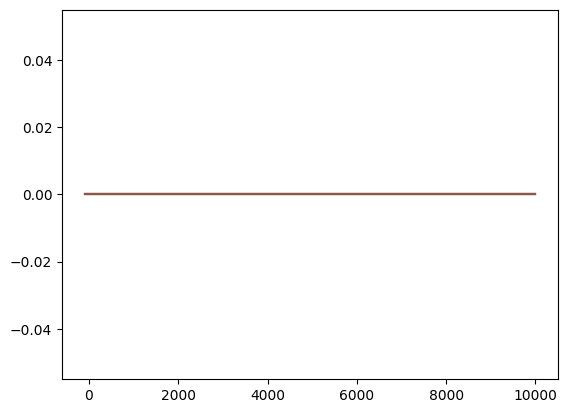

In [217]:
shotn = 204370
with h5py.File(f"/scratch/gpfs/aj17/datasets/D3D_shot_{shotn}_mdsplus.h5",'r') as hf:
    x =np.asarray(hf["\\D3D::TOP.NB.NB15L:PINJ_15L"]["time"])
    y =np.asarray(hf["\\D3D::TOP.NB.NB15L:PINJ_15L"]["values"])
    x_raw =np.asarray(hf["\\D3D::TOP.NB.NB15L:PTDATA_RAW"]["time"])
    y_raw =np.asarray(hf["\\D3D::TOP.NB.NB15L:PTDATA_RAW"]["values"])
    cal = np.asarray(hf["\\D3D::TOP.NB.NB15R:PTDATA_CAL"]['values'])
    

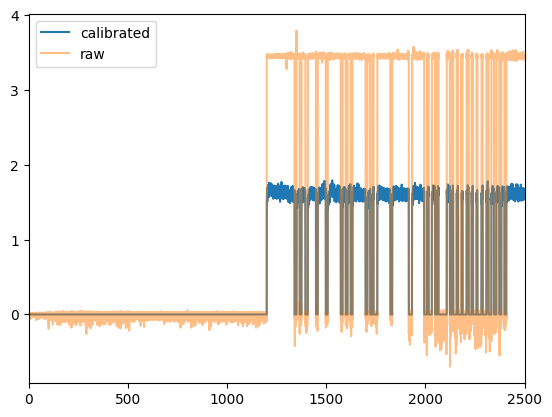

In [222]:
plt.plot(x,y*1e-6,label='calibrated')
plt.plot(x_raw,y_raw,alpha=0.5,label='raw')
plt.xlim([0,2500])
plt.legend()


In [213]:
cal

array([0., 0., 0., ..., 0., 0., 0.], shape=(131001,), dtype=float32)

In [214]:
y_raw

array([-0.00123262, -0.00508455,  0.        , ..., -0.00077039,
       -0.00184893,  0.00169485], shape=(1048576,), dtype=float32)

In [28]:
with open('/scratch/gpfs/aj17/datasets/fm_test/dynamicmodel/dataset/206527_df.pkl','rb') as fid:
    data = pickle.load(fid)

<Axes: xlabel='time'>

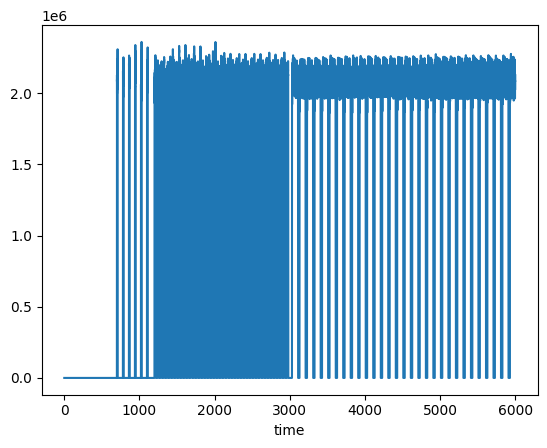

In [32]:
data['nbi']['bmspinj33l'].plot()

In [66]:
data_path = "/scratch/gpfs/aj17/datasets/fm_test/dynamicmodel/dataset/206527_df.pkl"
with open(data_path, "rb") as fh:
    data = pickle.load(fh)

nbi = data["nbi"]
beam_col = "bmspinj33l"
beam = nbi[beam_col]
t = beam.index.values.astype(np.float64)
v = beam.values.astype(np.float64)

avg_power = utils.compute_beam_avg_power(t, v)

# Print some diagnostics
peak = np.median(v[v > 0])
print(f"Beam: {beam_col}")
print(f"Peak power (median when ON): {peak:.0f}")
print(f"Time range: {t[0]:.1f} - {t[-1]:.1f} s")
print()

# Show duty cycle at various time points
is_on = v > 0.01 * v.max()
segments = []
changes = np.diff(is_on.astype(int))
change_idx = np.where(changes != 0)[0] + 1
boundaries = np.concatenate(([0], change_idx, [len(v)]))
for i in range(len(boundaries) - 1):
    si, ei = boundaries[i], boundaries[i + 1]
    segments.append((t[si], t[ei - 1], bool(is_on[si])))

print("Segment analysis:")
print(f"{'Start':>10s} {'End':>10s} {'State':>5s} {'Duration':>10s} {'Avg Power':>12s} {'Duty Cycle':>12s}")
for start, end, state in segments[:20]:
    dur = end - start
    label = "ON" if state else "OFF"
    avg_at_start = avg_power[np.argmin(np.abs(t - start))]
    duty = avg_at_start / peak if peak > 0 else 0
    print(f"{start:10.1f} {end:10.1f} {label:>5s} {dur:10.1f}s {avg_at_start:12.0f} {duty:12.1%}")

Beam: bmspinj33l
Peak power (median when ON): 2108811
Time range: 0.0 - 6000.0 s

Segment analysis:
     Start        End State   Duration    Avg Power   Duty Cycle
       0.0      700.0   OFF      700.0s            0         0.0%
     700.1      710.0    ON        9.9s       263814        12.5%
     710.0      780.0   OFF       70.0s       263814        12.5%
     780.2      790.0    ON        9.8s       262245        12.4%
     790.0      860.1   OFF       70.0s       262245        12.4%
     860.1      870.0    ON        9.9s       266590        12.6%
     870.0      940.0   OFF       70.0s       266590        12.6%
     940.2      950.0    ON        9.8s       267206        12.7%
     950.0     1020.1   OFF       70.0s       267206        12.7%
    1020.2     1030.0    ON        9.8s       266405        12.6%
    1030.1     1100.0   OFF       70.0s       266405        12.6%
    1100.1     1110.0    ON        9.9s       211919        10.0%
    1110.0     1200.1   OFF       90.0s    

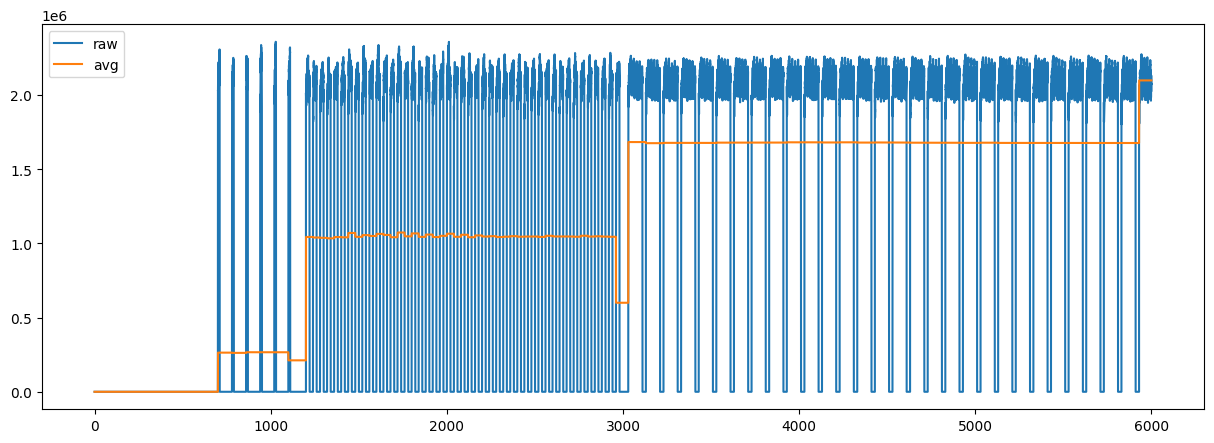

In [69]:
fig, axs = plt.subplots(ncols=1, nrows=1, figsize=(15,5))
plt.plot(t,v, label='raw')
plt.plot(t,avg_power, label='avg')
plt.legend()